<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/machine_learning/lab%20-%20Support%20Vector%20Machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines (SVM)

**Theory:** [notes/machine_learning/05_support_vector_classifier.ipynb](../../notes/machine_learning/05_support_vector_classifier.ipynb) (margin $2/\|\mathbf{w}\|$, hard-margin QP, Lagrange dual, soft margin, kernel trick, hinge loss, support vectors).

A **Support Vector Machine** (Cortes & Vapnik, 1995) looks for the decision boundary that leaves the widest possible margin between the two classes. In this lab we build intuition with plots and then use scikit-learn.

Labels follow the SVM convention $y \in \{-1, +1\}$ in the maths; scikit-learn accepts 0/1 and handles this for you.

### Learning Objectives
1. See why the maximum-margin boundary is a sensible choice
2. Identify support vectors and see that only they define the model
3. Use the kernel trick to get non-linear boundaries
4. Understand the role of $C$ (soft margin) and tune it with cross-validation

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## Motivating Support Vector Machines

At this point, we consider the simple case of a classification task in which the two classes of points are well separated.

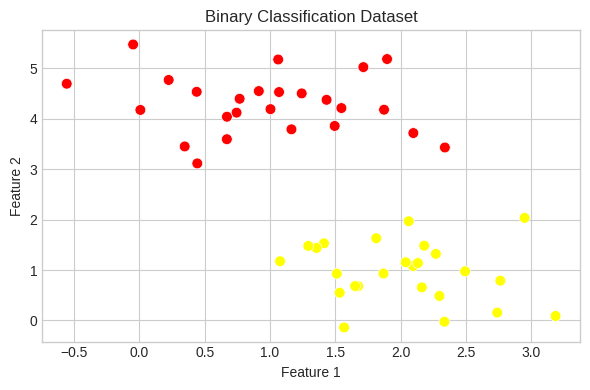

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.tight_layout()
plt.show()

We want a hyperplane that separates these two sets of points, and so gives us a classifier. With just two features we could even draw that line by hand.

However, there are infinitely many lines that separate the data perfectly. For example:

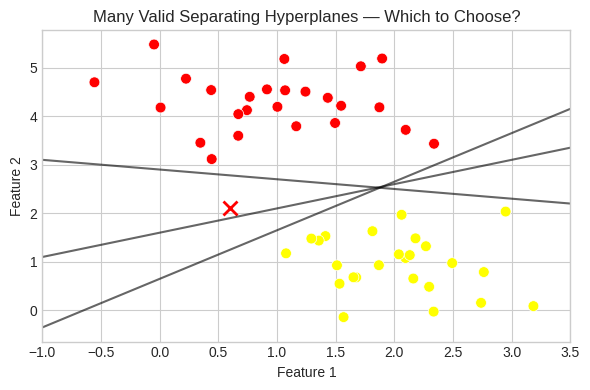

In [3]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)
for slope, intercept in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, slope * xfit + intercept, '-k', alpha=0.6)
plt.xlim(-1, 3.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Many Valid Separating Hyperplanes — Which to Choose?')
plt.tight_layout()
plt.show()

Depending on which line you choose, a new point (e.g. the one marked with "x") gets a different label.

We need a criterion to pick the *best* line.

## Support Vector Machines: Maximizing the *Margin*

Instead of drawing only a line, draw a band around each line that reaches up to the nearest point. The width of this band is the *margin*.

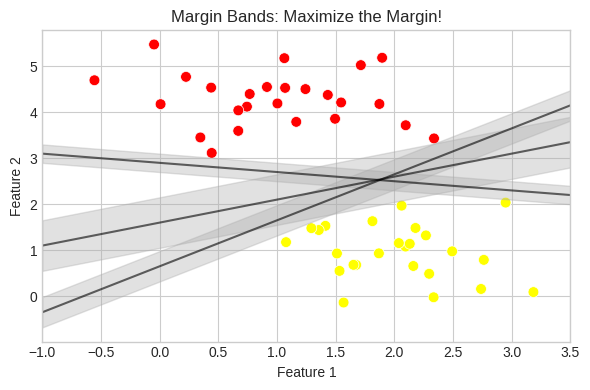

In [4]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
for slope, intercept, margin in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = slope * xfit + intercept
    plt.plot(xfit, yfit, '-k', alpha=0.6)
    plt.fill_between(xfit, yfit - margin, yfit + margin,
                     edgecolor='none', color='#AAAAAA', alpha=0.35)
plt.xlim(-1, 3.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Margin Bands: Maximize the Margin!')
plt.tight_layout()
plt.show()

The SVM picks the line with the widest margin: the *maximum-margin* estimator. In the plot above, the middle line is clearly the best of the three.

### The optimisation problem (in short)

The decision boundary is $\mathbf{w}^\top\mathbf{x} + b = 0$. After scaling so that the closest points satisfy $y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) = 1$, the margin width is $2/\|\mathbf{w}\|$, so maximising it means

$$\min_{\mathbf{w}, b} \tfrac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) \geq 1 \;\; \forall i.$$

This is a convex quadratic program. Its Lagrange dual depends on the data only through inner products $\langle\mathbf{x}^{(i)}, \mathbf{x}^{(j)}\rangle$, which is what makes the kernel trick possible later. See notes 05, sections 4 to 7, for the derivation.

### Fitting an SVM with scikit-learn

We use `SVC(kernel='linear', C=1e10)`: a very large $C$ gives an (almost) hard margin. Internally, `fit` solves the dual problem with the SMO algorithm (Platt, 1998).

In [5]:
from sklearn.svm import SVC  # "Support vector classifier"

model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

To better visualize what's happening here, let's create a quick convenience function that will plot SVM decision boundaries for us:

In [6]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision boundary, the margins and (optionally) the support vectors of a 2D SVC."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # evaluate the decision function on a grid covering the current axes
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    grid = np.vstack([XX.ravel(), YY.ravel()]).T
    P = model.decision_function(grid).reshape(XX.shape)

    # decision boundary (level 0) and margins (levels -1 and +1)
    ax.contour(XX, YY, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # circle the support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

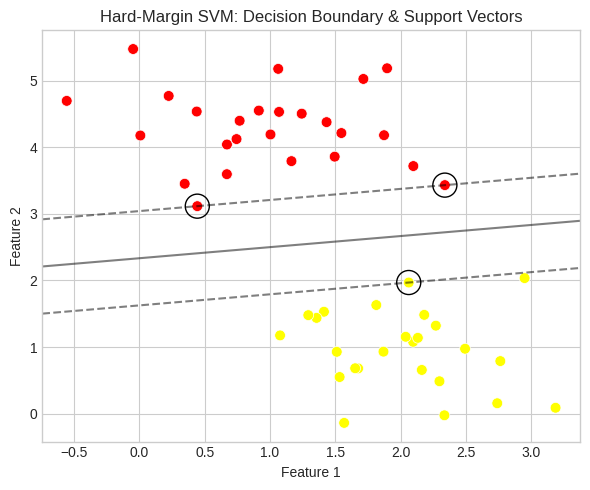

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(model)
plt.title('Hard-Margin SVM: Decision Boundary & Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

The solid line is the boundary that maximises the margin; the dashed lines are the margins. A few training points touch the margin: they are the *support vectors*, and they give the algorithm its name (circled above).

Let's see which points they are:

In [8]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

**Key property of SVMs: only support vectors matter.**

From the dual, $\mathbf{w} = \sum_{i \in \text{SV}} \alpha_i y^{(i)} \mathbf{x}^{(i)}$. Points away from the margin have $\alpha_i = 0$ and do not contribute to the model (see notes 05, sections 7 and 11). In contrast, in logistic regression every point contributes.

Let's check this empirically: adding more points far from the margin should not change the boundary.

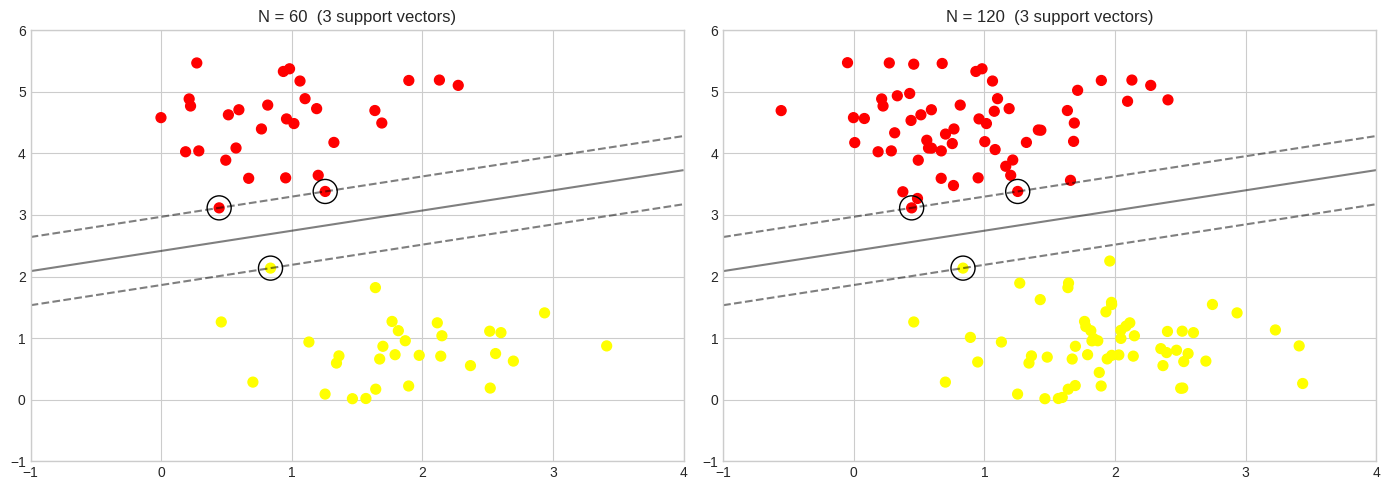

In [9]:
def plot_svm(N=10, ax=None):
    # take the first N points of a fixed dataset and fit a hard-margin SVM
    X_n, y_n = make_blobs(n_samples=200, centers=2, random_state=0, cluster_std=0.60)
    X_n, y_n = X_n[:N], y_n[:N]
    model_n = SVC(kernel='linear', C=1e10).fit(X_n, y_n)

    ax = ax or plt.gca()
    ax.scatter(X_n[:, 0], X_n[:, 1], c=y_n, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model_n, ax)
    return model_n

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for axi, N in zip(ax, [60, 120]):
    m = plot_svm(N, axi)
    axi.set_title(f'N = {N}  ({len(m.support_vectors_)} support vectors)')
plt.tight_layout()
plt.show()

On the left, the model is trained on 60 points; on the right, on 120 points. The model has not changed: the same three support vectors define the boundary in both panels. This insensitivity to distant points is one of the strengths of the SVM.

### Beyond Linear Boundaries: The Kernel Trick

Because the dual only uses inner products, we can replace $\langle\mathbf{x}^{(i)}, \mathbf{x}^{(j)}\rangle$ with a **kernel** $K(\mathbf{x}, \mathbf{z}) = \langle\phi(\mathbf{x}), \phi(\mathbf{z})\rangle$. This fits a linear SVM in a (possibly huge) feature space $\phi(\mathbf{x})$ without ever computing $\phi$.

Common choices in scikit-learn: `'linear'`, `'poly'` $(\gamma\mathbf{x}^\top\mathbf{z} + r)^d$ and `'rbf'` $\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$. See notes 05, section 9.

First, let's see a linear SVM fail on data that is not linearly separable:

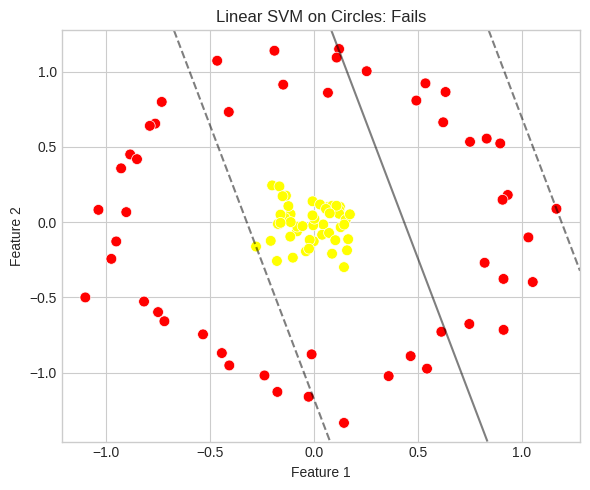

In [10]:
from sklearn.datasets import make_circles

# one class inside a ring of the other class
X, y = make_circles(100, factor=0.1, noise=0.1, random_state=0)

clf = SVC(kernel='linear').fit(X, y)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(clf, plot_support=False)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM on Circles: Fails')
plt.tight_layout()
plt.show()

No line will *ever* separate this data. But we can project it into a higher dimension where a linear separator *is* enough.

For example, a simple projection is a *radial basis function* centred on the middle point (0, 0):

In [11]:
# new feature: r = exp(-||x||^2), large near the centre, small far away
r = np.exp(-(X ** 2).sum(axis=1))

We can visualize this extra data dimension using a three-dimensional plot.

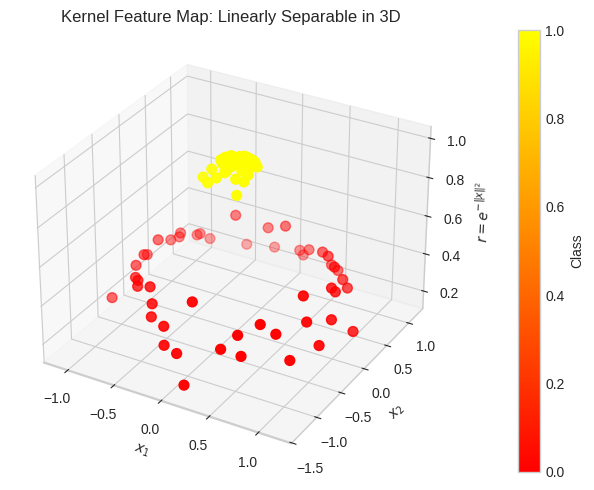

In [12]:
def plot_3D(X, r, y):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_zlabel(r'$r = e^{-\|x\|^2}$')
    ax.set_title('Kernel Feature Map: Linearly Separable in 3D')
    plt.colorbar(sc, ax=ax, pad=0.1, label='Class')
    plt.tight_layout()
    plt.show()

plot_3D(X, r, y)

With this extra dimension the data becomes trivially linearly separable: a plane at, for example, $r = 0.7$ splits the two classes (the maximum-margin plane may be slightly higher or lower).

Here we had to choose and tune the projection by hand: had we not centred the radial basis function in the right place, we would not get such a clean result. In general we want this choice to be made automatically.

One strategy is to centre a basis function at *every* point in the dataset and let the SVM sift through the results. This is a *kernel transformation*, because it is built from a similarity (kernel) between each pair of points.

Projecting $N$ points into $N$ dimensions would be expensive for large $N$. The kernel trick avoids this: the fit is done implicitly, without ever building that representation.

In scikit-learn we only need to change the `kernel` hyperparameter to `'rbf'`:

In [13]:
clf = SVC(kernel='rbf', C=1e6)  # the default kernel is already 'rbf'; above we set 'linear' explicitly
clf.fit(X, y)

SVC(C=1000000.0)

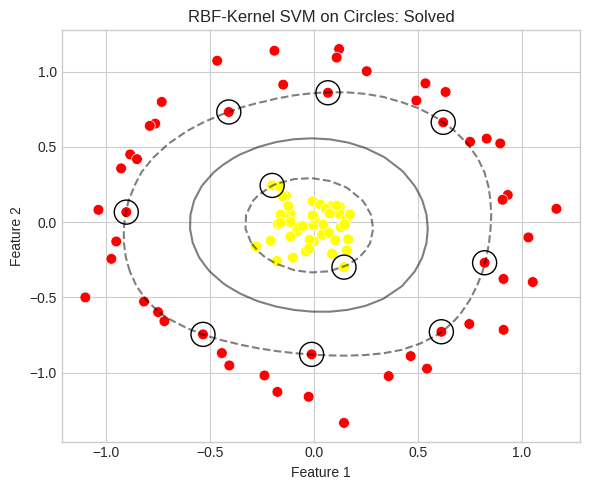

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(clf)  # also circles the support vectors
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('RBF-Kernel SVM on Circles: Solved')
plt.tight_layout()
plt.show()

With the kernelized SVM we learned a suitable non-linear decision boundary. The support vectors in this case are:

In [15]:
clf.support_vectors_

array([[-0.40867925,  0.73225992],
       [-0.90136274,  0.06675095],
       [ 0.62194713,  0.66363424],
       [-0.53262577, -0.74551749],
       [-0.01059175, -0.87830074],
       [ 0.06782759,  0.86000564],
       [ 0.82087304, -0.26971282],
       [ 0.61304799, -0.72820082],
       [-0.20035062,  0.24428624],
       [ 0.14497035, -0.29878438]])

### Soft-Margin SVM: Handling Non-Separable Data

Real data is rarely perfectly separable. The soft-margin SVM allows some points inside the margin (or even misclassified) and pays a penalty for it. Written with the hinge loss:

$$\min_{\mathbf{w}, b} \; \tfrac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^m \max\bigl(0,\, 1 - y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b)\bigr)$$

- Large $C$: violations are expensive, so the margin is narrow (risk of overfitting).
- Small $C$: violations are cheap, so the margin is wide (risk of underfitting).

See notes 05, sections 8 and 10, for slack variables and the hinge loss.

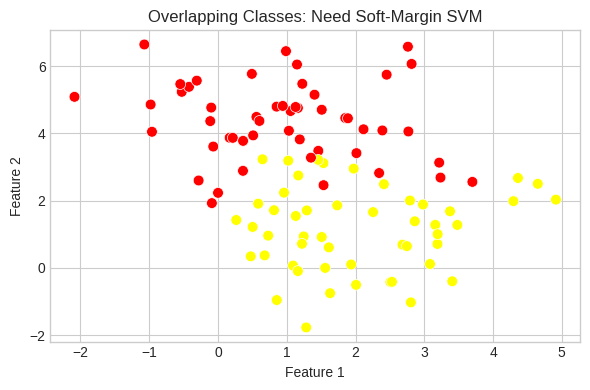

In [16]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Overlapping Classes: Need Soft-Margin SVM')
plt.tight_layout()
plt.show()

Here no line separates the classes perfectly, so we need a *soft* margin. Let's see how $C$ changes the solution.

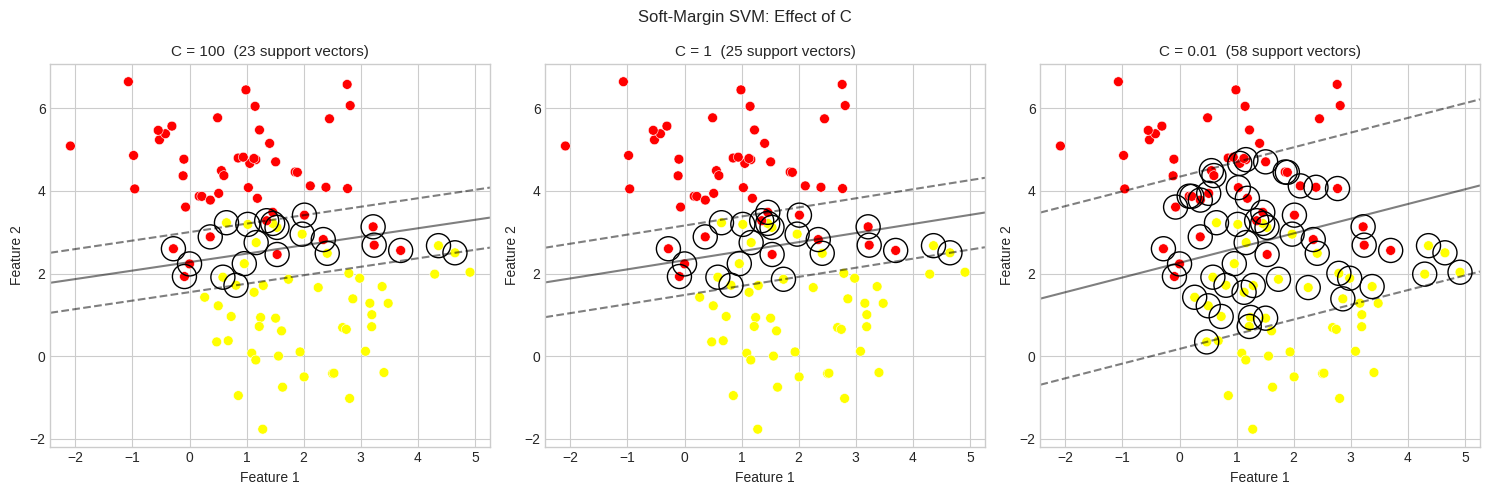

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for axi, C in zip(ax, [100.0, 1.0, 0.01]):
    model_c = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn',
                edgecolors='white', linewidths=0.4)
    plot_svc_decision_function(model_c, axi)  # also circles the support vectors
    axi.set_title(f'C = {C:g}  ({len(model_c.support_vectors_)} support vectors)', fontsize=11)
    axi.set_xlabel('Feature 1')
    axi.set_ylabel('Feature 2')

fig.suptitle('Soft-Margin SVM: Effect of C', fontsize=12)
plt.tight_layout()
plt.show()

Smaller $C$ gives a wider margin with more points inside it, so more support vectors. The best $C$ depends on the dataset and should be chosen on held-out data. First a simple train/validation split, then cross-validation.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# a noisier dataset, split into train and validation
X, y = make_blobs(n_samples=500, centers=2, random_state=0, cluster_std=2)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"{'C':>8}  |  Val accuracy")
print("-" * 26)
for C in [100, 1, 0.01]:
    clf_c = SVC(kernel='rbf', C=C).fit(X_train, y_train)
    acc = accuracy_score(y_valid, clf_c.predict(X_valid))
    print(f"{C:>8}  |  {acc:.4f}")

       C  |  Val accuracy
--------------------------
     100  |  0.8200
       1  |  0.8500
    0.01  |  0.7100


### Hyperparameter Tuning with Cross-Validation

Instead of trying a few values by hand, `GridSearchCV` searches the grid systematically with 5-fold cross-validation:

Best parameters:  {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV accuracy: 0.9067


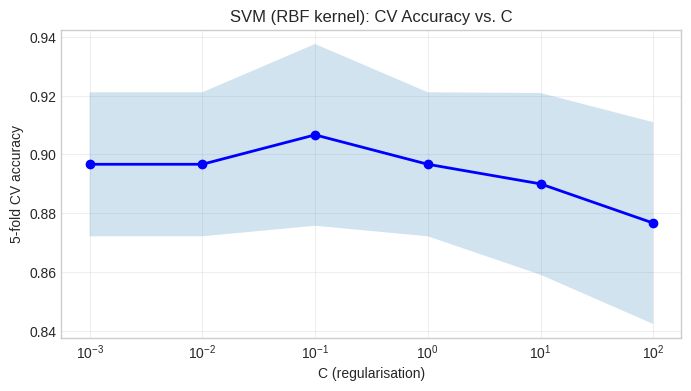

In [19]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_cv, y_cv = make_blobs(n_samples=300, centers=2, random_state=0, cluster_std=1.5)

# scale the features, then fit the SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C':      [0.001, 0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_cv, y_cv)

print(f"Best parameters:  {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# CV accuracy vs. C for the RBF kernel (gamma='scale')
results = pd.DataFrame(grid.cv_results_)
rbf = results[(results['param_svm__kernel'] == 'rbf') & (results['param_svm__gamma'] == 'scale')]
C_vals = rbf['param_svm__C'].astype(float).to_numpy()
scores = rbf['mean_test_score'].to_numpy()
stds = rbf['std_test_score'].to_numpy()

plt.figure(figsize=(8, 4))
plt.semilogx(C_vals, scores, 'bo-', lw=2)
plt.fill_between(C_vals, scores - stds, scores + stds, alpha=0.2)
plt.xlabel('C (regularisation)')
plt.ylabel('5-fold CV accuracy')
plt.title('SVM (RBF kernel): CV Accuracy vs. C')
plt.grid(alpha=0.3)
plt.show()

## Support Vector Machine Summary

| Property | SVM | Logistic Regression |
|----------|-----|---------------------|
| Loss function | Hinge loss $\max(0, 1-yf(x))$ | Log-loss |
| Probabilistic output | Not native (needs Platt scaling) | Yes |
| Influence of data points | Only support vectors | All training points |
| Non-linear boundaries | Via kernel trick | Via feature engineering |
| Large-scale data | Can be slow for $m > 10^5$ | Scales well (SGD) |

**Key takeaways:**
1. SVMs find the **maximum-margin** decision boundary.
2. The dual depends only on inner products, so the **kernel trick** gives non-linear boundaries without computing high-dimensional features.
3. $C$ controls the softness of the margin: large $C$ fits the training data more tightly, small $C$ gives a wider, more tolerant margin. Tune it with cross-validation.
4. Only the **support vectors** define the model.